Данные загружены:
  Entropy (before IQR): 2 записей
  Entropy (after IQR): 2 записей
  Kernel (after IQR): 6 записей


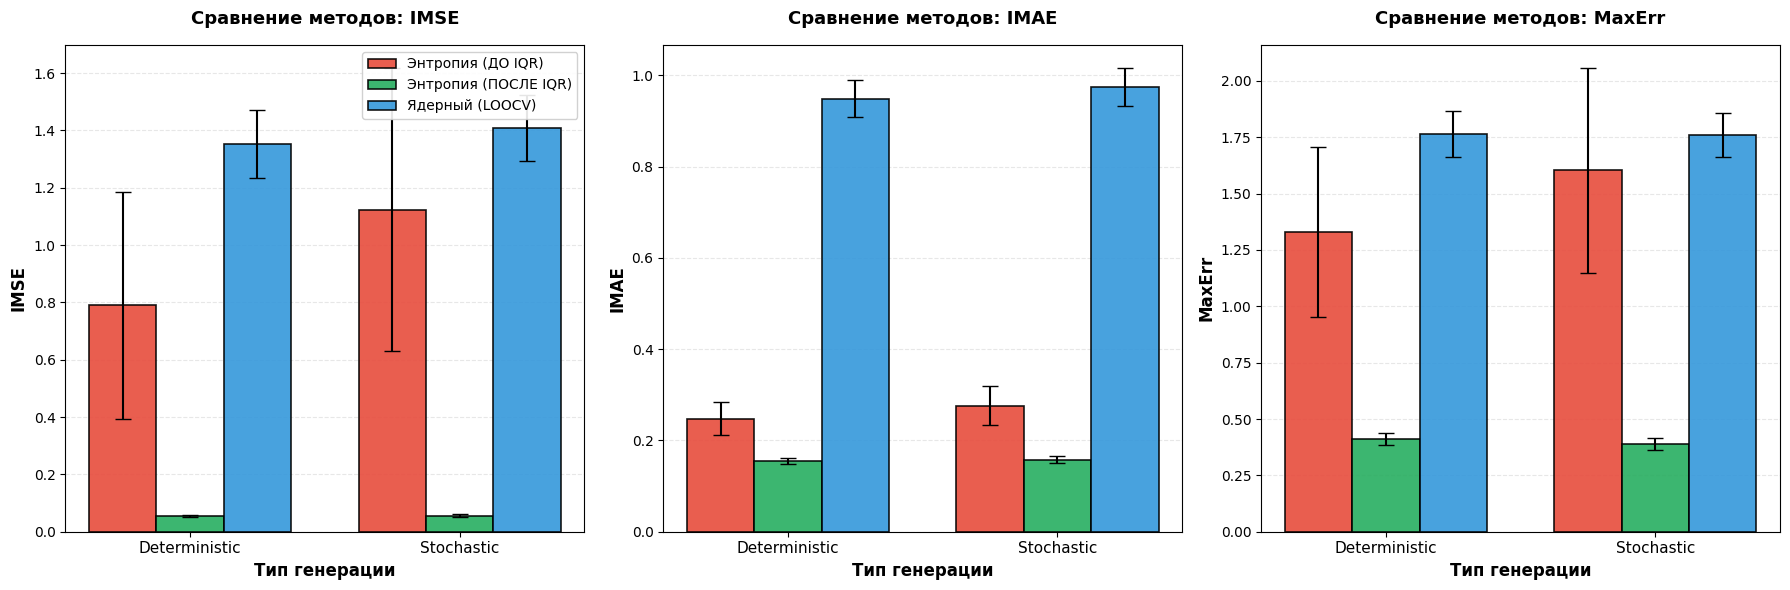

  IMSE (deterministic): p_value = 0.0000000000
  IMSE (stochastic): p_value = 0.0000000000
  IMAE (deterministic): p_value = 0.0000000000
  IMAE (stochastic): p_value = 0.0000000000
  MAXERR (deterministic): p_value = 0.0000000000
  MAXERR (stochastic): p_value = 0.0000000000

P-VALUE: ЭНТРОПИЯ (ПОСЛЕ) vs ЯДЕРНЫЙ (ПОСЛЕ)
generation_type  deterministic  stochastic
metric                                    
IMSE                       0.0         0.0
IMAE                       0.0         0.0
MAXERR                     0.0         0.0


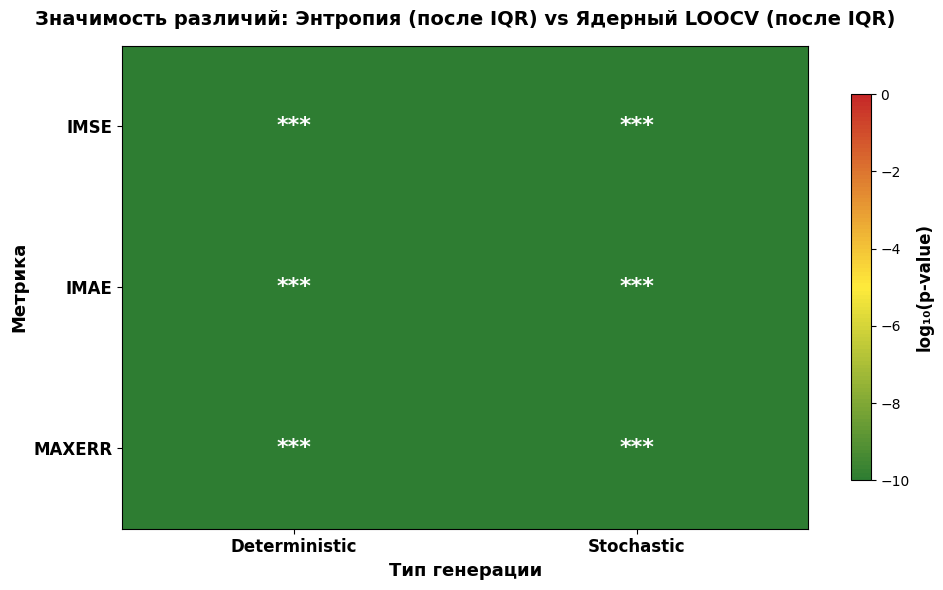

  IMSE (deterministic): p_value = 0.0080321007
  IMSE (stochastic): p_value = 0.2734762407
  IMAE (deterministic): p_value = 0.0000000000
  IMAE (stochastic): p_value = 0.0000000000
  MAXERR (deterministic): p_value = 0.0294899177
  MAXERR (stochastic): p_value = 0.5093638864

P-VALUE: ЭНТРОПИЯ (ДО) vs ЯДЕРНЫЙ (ПОСЛЕ)
generation_type  deterministic  stochastic
metric                                    
IMSE                  0.008032    0.273476
IMAE                  0.000000    0.000000
MAXERR                0.029490    0.509364


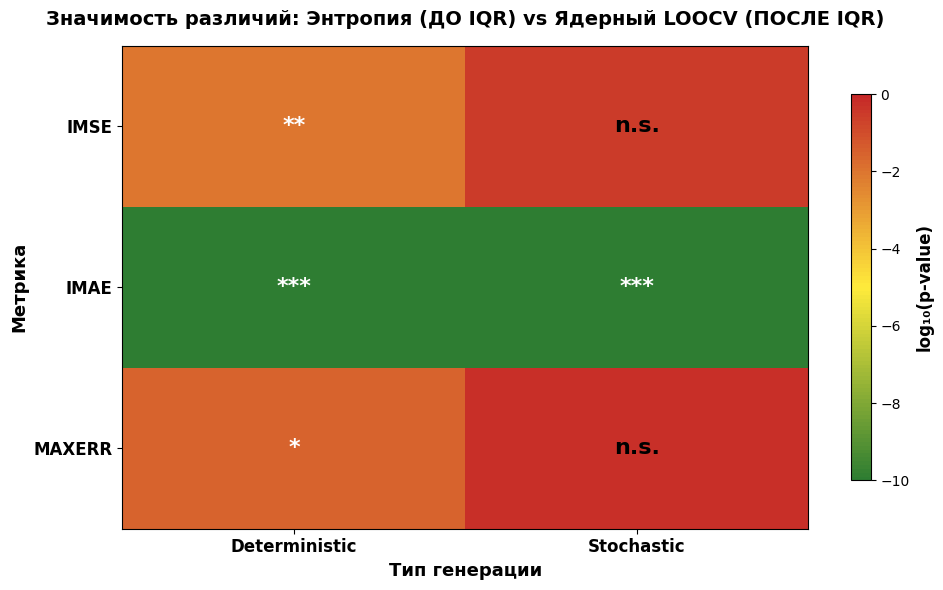

  IMSE (deterministic): improvement = 95.9%
  IMSE (stochastic): improvement = 96.0%
  IMAE (deterministic): improvement = 83.6%
  IMAE (stochastic): improvement = 83.8%
  MAXERR (deterministic): improvement = 76.7%
  MAXERR (stochastic): improvement = 77.8%

ПРЕИМУЩЕСТВО ЭНТРОПИИ (%) - ПОСЛЕ IQR
generation_type  deterministic  stochastic
metric                                    
IMSE                 95.910751   95.986689
IMAE                 83.606160   83.792899
MAXERR               76.732982   77.801699


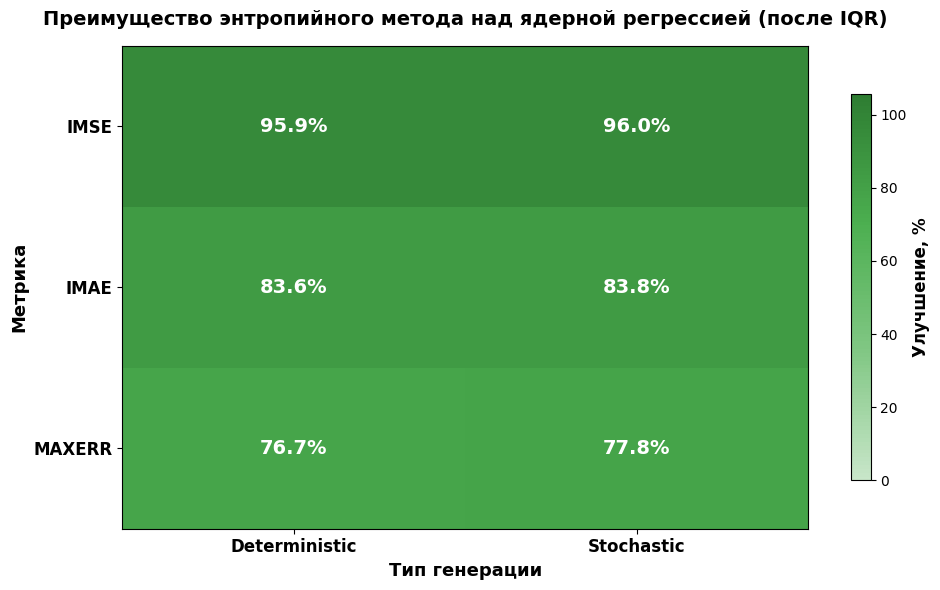

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from matplotlib.colors import LinearSegmentedColormap

# =============================================================================
# ЗАГРУЗКА ДАННЫХ
# =============================================================================

df_entropy_before = pd.read_csv('entropy_mixture_results_before_iqr.csv')
df_entropy_after = pd.read_csv('entropy_mixture_results_after_iqr.csv')
df_kernel = pd.read_csv('kernel_regression_mixture_results_after_iqr.csv')

print("Данные загружены:")
print(f"  Entropy (before IQR): {len(df_entropy_before)} записей")
print(f"  Entropy (after IQR): {len(df_entropy_after)} записей")
print(f"  Kernel (after IQR): {len(df_kernel)} записей")

# =============================================================================
# ЕДИНАЯ ФУНКЦИЯ T-ТЕСТА УЭЛЧА
# =============================================================================

def calculate_ttest_pvalue(row1, row2, metric_prefix):
    """
    T-тест Уэлча для двух независимых выборок с разными дисперсиями
    """
    mean_col = f'{metric_prefix}_mean'
    sem_col = f'{metric_prefix}_sem'
    
    mean1 = float(row1[mean_col])
    sem1 = float(row1[sem_col])
    n1 = int(row1['n_valid'])
    
    mean2 = float(row2[mean_col])
    sem2 = float(row2[sem_col])
    n2 = int(row2['n_valid'])
    
    # T-статистика Уэлча
    t_stat = (mean1 - mean2) / np.sqrt(sem1**2 + sem2**2)
    
    # Степени свободы (формула Уэлча-Саттертуэйта)
    df = (sem1**2 + sem2**2)**2 / (sem1**4/(n1-1) + sem2**4/(n2-1))
    
    # Двусторонний p-value
    p_value = 2 * (1 - stats.t.cdf(abs(t_stat), df))
    
    return p_value, t_stat, df

# =============================================================================
# ГРАФИК 1: СРАВНЕНИЕ ПО МЕТОДАМ (3 метрики)
# =============================================================================

def plot_method_comparison():
    """
    График: Сравнение энтропийного метода (до/после IQR) и лучшего ядерного метода
    """
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    metrics = [
        ('imse_mean', 'imse_sem', 'IMSE', '#C84B31'),
        ('imae_mean', 'imae_sem', 'IMAE', '#2E86AB'),
        ('maxerr_mean', 'maxerr_sem', 'MaxErr', '#F18F01')
    ]
    
    method_colors = {
        'entropy_before': '#E74C3C',
        'entropy_after': '#27AE60',
        'kernel_best': '#3498DB'
    }
    
    method_labels = {
        'entropy_before': 'Энтропия (ДО IQR)',
        'entropy_after': 'Энтропия (ПОСЛЕ IQR)',
        'kernel_best': 'Ядерный (LOOCV)'
    }
    
    x_pos = np.arange(2)
    width = 0.25
    
    for ax_idx, (mean_col, sem_col, metric_name, color) in enumerate(metrics):
        ax = axes[ax_idx]
        
        for i, method in enumerate(['entropy_before', 'entropy_after', 'kernel_best']):
            if method == 'kernel_best':
                df_method = pd.DataFrame([
                    df_kernel[(df_kernel['method'] == 'loocv') & (df_kernel['generation_type'] == 'deterministic')].iloc[0],
                    df_kernel[(df_kernel['method'] == 'loocv') & (df_kernel['generation_type'] == 'stochastic')].iloc[0]
                ])
            else:
                df_source = df_entropy_before if method == 'entropy_before' else df_entropy_after
                df_method = pd.DataFrame([
                    df_source[df_source['generation_type'] == 'deterministic'].iloc[0],
                    df_source[df_source['generation_type'] == 'stochastic'].iloc[0]
                ])
            
            means = df_method[mean_col].values
            errors = 1.96 * df_method[sem_col].values
            
            positions = x_pos + (i - 1) * width
            ax.bar(positions, means, width, yerr=errors, capsize=6,
                   color=method_colors[method], edgecolor='black', linewidth=1.2,
                   error_kw={'elinewidth': 1.5}, alpha=0.9,
                   label=method_labels[method] if ax_idx == 0 else "")
        
        ax.set_xlabel('Тип генерации', fontsize=12, fontweight='bold')
        ax.set_ylabel(metric_name, fontsize=12, fontweight='bold')
        ax.set_title(f'Сравнение методов: {metric_name}', fontsize=13, fontweight='bold', pad=15)
        ax.set_xticks(x_pos)
        ax.set_xticklabels(['Deterministic', 'Stochastic'], fontsize=11)
        ax.grid(axis='y', alpha=0.3, linestyle='--')
        ax.set_axisbelow(True)
        
        if ax_idx == 0:
            ax.legend(loc='upper right', fontsize=10, framealpha=0.9)
    
    plt.tight_layout()
    plt.savefig('method_comparison_by_generation.png', dpi=300, bbox_inches='tight')
    plt.show()

plot_method_comparison()

# =============================================================================
# ГРАФИК 2: ТЕПЛОВАЯ КАРТА P-VALUE (ЭНТРОПИЯ ПОСЛЕ vs ЯДЕРНЫЙ ПОСЛЕ)
# =============================================================================

def plot_pvalue_heatmap_entropy_vs_kernel():
    """
    Тепловая карта p-values: Энтропия (после IQR) vs Ядерный (после IQR)
    """
    metrics = ['imse', 'imae', 'maxerr']
    gen_types = ['deterministic', 'stochastic']
    
    pvalue_data = []
    
    for metric in metrics:
        for gen in gen_types:
            entropy_row = df_entropy_after[df_entropy_after['generation_type'] == gen].iloc[0]
            kernel_row = df_kernel[(df_kernel['method'] == 'loocv') & (df_kernel['generation_type'] == gen)].iloc[0]
            
            p_val, t_stat, df = calculate_ttest_pvalue(entropy_row, kernel_row, metric)
            
            print(f"  {metric.upper()} ({gen}): p_value = {p_val:.10f}")
            
            pvalue_data.append({
                'metric': metric.upper(),  # 'IMSE', 'IMAE', 'MAXERR'
                'generation_type': gen,
                'p_value': p_val
            })
    
    df_pvalue = pd.DataFrame(pvalue_data)
    
    heatmap_data = df_pvalue.pivot(index='metric', columns='generation_type', values='p_value')
    
    # 🔧 ИСПРАВЛЕНИЕ: Используем тот же регистр, что и в данных (все заглавные)
    heatmap_data = heatmap_data.reindex(index=['IMSE', 'IMAE', 'MAXERR'])
    heatmap_data = heatmap_data.reindex(columns=['deterministic', 'stochastic'])
    
    print("\n" + "=" * 80)
    print("P-VALUE: ЭНТРОПИЯ (ПОСЛЕ) vs ЯДЕРНЫЙ (ПОСЛЕ)")
    print("=" * 80)
    print(heatmap_data.to_string())
    
    fig, ax = plt.subplots(figsize=(10, 6))
    
    cmap = LinearSegmentedColormap.from_list(
        'significance',
        ['#2E7D32', '#FFEB3B', '#C62828'],
        N=100
    )
    
    data_for_plot = heatmap_data.values.copy()
    
    im = ax.imshow(np.log10(data_for_plot + 1e-15),
                   aspect='auto', cmap=cmap,
                   vmin=np.log10(1e-10), vmax=np.log10(1.0))
    
    for i in range(len(heatmap_data.index)):
        for j in range(len(heatmap_data.columns)):
            val = heatmap_data.values[i, j]
            
            if pd.isna(val) or val < 1e-10:
                text = '***'
                color = 'white'
            elif val < 0.001:
                text = '***'
                color = 'white'
            elif val < 0.01:
                text = '**'
                color = 'white'
            elif val < 0.05:
                text = '*'
                color = 'white'
            else:
                text = 'n.s.'
                color = 'black'
            
            ax.text(j, i, text, ha='center', va='center',
                   fontsize=16, fontweight='bold', color=color)
    
    ax.set_xticks(range(len(heatmap_data.columns)))
    ax.set_yticks(range(len(heatmap_data.index)))
    ax.set_xticklabels(['Deterministic', 'Stochastic'], fontsize=12, fontweight='bold')
    ax.set_yticklabels(heatmap_data.index, fontsize=12, fontweight='bold')
    ax.set_xlabel('Тип генерации', fontsize=13, fontweight='bold')
    ax.set_ylabel('Метрика', fontsize=13, fontweight='bold')
    ax.set_title('Значимость различий: Энтропия (после IQR) vs Ядерный LOOCV (после IQR)',
                fontsize=14, fontweight='bold', pad=15)
    
    cbar = plt.colorbar(im, ax=ax, shrink=0.8)
    cbar.set_label('log₁₀(p-value)', fontsize=12, fontweight='bold')
    
    plt.tight_layout()
    plt.savefig('pvalue_heatmap_entropy_vs_kernel.png', dpi=300, bbox_inches='tight')
    plt.show()

plot_pvalue_heatmap_entropy_vs_kernel()

# =============================================================================
# ГРАФИК 3: ТЕПЛОВАЯ КАРТА P-VALUE (ЭНТРОПИЯ ДО vs ЯДЕРНЫЙ ПОСЛЕ)
# =============================================================================

def plot_pvalue_heatmap_entropy_before_vs_kernel_after():
    """
    Тепловая карта p-values: Энтропия (ДО IQR) vs Ядерный (ПОСЛЕ IQR)
    """
    metrics = ['imse', 'imae', 'maxerr']
    gen_types = ['deterministic', 'stochastic']
    
    pvalue_data = []
    
    for metric in metrics:
        for gen in gen_types:
            entropy_row = df_entropy_before[df_entropy_before['generation_type'] == gen].iloc[0]
            kernel_row = df_kernel[(df_kernel['method'] == 'loocv') & (df_kernel['generation_type'] == gen)].iloc[0]
            
            p_val, t_stat, df = calculate_ttest_pvalue(entropy_row, kernel_row, metric)
            
            print(f"  {metric.upper()} ({gen}): p_value = {p_val:.10f}")
            
            pvalue_data.append({
                'metric': metric.upper(),
                'generation_type': gen,
                'p_value': p_val
            })
    
    df_pvalue = pd.DataFrame(pvalue_data)
    
    heatmap_data = df_pvalue.pivot(index='metric', columns='generation_type', values='p_value')
    
    # 🔧 ИСПРАВЛЕНИЕ: Используем тот же регистр, что и в данных (все заглавные)
    heatmap_data = heatmap_data.reindex(index=['IMSE', 'IMAE', 'MAXERR'])
    heatmap_data = heatmap_data.reindex(columns=['deterministic', 'stochastic'])
    
    print("\n" + "=" * 80)
    print("P-VALUE: ЭНТРОПИЯ (ДО) vs ЯДЕРНЫЙ (ПОСЛЕ)")
    print("=" * 80)
    print(heatmap_data.to_string())
    
    fig, ax = plt.subplots(figsize=(10, 6))
    
    cmap = LinearSegmentedColormap.from_list(
        'significance',
        ['#2E7D32', '#FFEB3B', '#C62828'],
        N=100
    )
    
    data_for_plot = heatmap_data.values.copy()
    
    im = ax.imshow(np.log10(data_for_plot + 1e-15),
                   aspect='auto', cmap=cmap,
                   vmin=np.log10(1e-10), vmax=np.log10(1.0))
    
    for i in range(len(heatmap_data.index)):
        for j in range(len(heatmap_data.columns)):
            val = heatmap_data.values[i, j]
            
            if pd.isna(val) or val < 1e-10:
                text = '***'
                color = 'white'
            elif val < 0.001:
                text = '***'
                color = 'white'
            elif val < 0.01:
                text = '**'
                color = 'white'
            elif val < 0.05:
                text = '*'
                color = 'white'
            else:
                text = 'n.s.'
                color = 'black'
            
            ax.text(j, i, text, ha='center', va='center',
                   fontsize=16, fontweight='bold', color=color)
    
    ax.set_xticks(range(len(heatmap_data.columns)))
    ax.set_yticks(range(len(heatmap_data.index)))
    ax.set_xticklabels(['Deterministic', 'Stochastic'], fontsize=12, fontweight='bold')
    ax.set_yticklabels(heatmap_data.index, fontsize=12, fontweight='bold')
    ax.set_xlabel('Тип генерации', fontsize=13, fontweight='bold')
    ax.set_ylabel('Метрика', fontsize=13, fontweight='bold')
    ax.set_title('Значимость различий: Энтропия (ДО IQR) vs Ядерный LOOCV (ПОСЛЕ IQR)',
                fontsize=14, fontweight='bold', pad=15)
    
    cbar = plt.colorbar(im, ax=ax, shrink=0.8)
    cbar.set_label('log₁₀(p-value)', fontsize=12, fontweight='bold')
    
    plt.tight_layout()
    plt.savefig('pvalue_heatmap_entropy_before_vs_kernel_after.png', dpi=300, bbox_inches='tight')
    plt.show()

plot_pvalue_heatmap_entropy_before_vs_kernel_after()

# =============================================================================
# ГРАФИК 4: ТЕПЛОВАЯ КАРТА ПРЕИМУЩЕСТВА ЭНТРОПИИ (%)
# =============================================================================

def plot_advantage_heatmap():
    """
    Тепловая карта: Преимущество энтропийного метода над ядерным (после IQR)
    """
    metrics = ['imse', 'imae', 'maxerr']
    gen_types = ['deterministic', 'stochastic']
    
    advantage_data = []
    
    for metric in metrics:
        for gen in gen_types:
            entropy_row = df_entropy_after[df_entropy_after['generation_type'] == gen].iloc[0]
            kernel_row = df_kernel[(df_kernel['method'] == 'loocv') & (df_kernel['generation_type'] == gen)].iloc[0]
            
            mean_col = f'{metric}_mean'
            
            entropy_mean = float(entropy_row[mean_col])
            kernel_mean = float(kernel_row[mean_col])
            
            improvement_pct = (kernel_mean - entropy_mean) / kernel_mean * 100
            
            print(f"  {metric.upper()} ({gen}): improvement = {improvement_pct:.1f}%")
            
            advantage_data.append({
                'metric': metric.upper(),  # 'IMSE', 'IMAE', 'MAXERR'
                'generation_type': gen,
                'improvement_pct': improvement_pct
            })
    
    df_advantage = pd.DataFrame(advantage_data)
    
    heatmap_data = df_advantage.pivot(index='metric', columns='generation_type', values='improvement_pct')
    
    # 🔧 ИСПРАВЛЕНИЕ: Используем тот же регистр, что и в данных (все заглавные)
    heatmap_data = heatmap_data.reindex(index=['IMSE', 'IMAE', 'MAXERR'])
    heatmap_data = heatmap_data.reindex(columns=['deterministic', 'stochastic'])
    
    print("\n" + "=" * 80)
    print("ПРЕИМУЩЕСТВО ЭНТРОПИИ (%) - ПОСЛЕ IQR")
    print("=" * 80)
    print(heatmap_data.to_string())
    
    fig, ax = plt.subplots(figsize=(10, 6))
    
    cmap = LinearSegmentedColormap.from_list(
        'green_gradient',
        ['#C8E6C9', '#81C784', '#4CAF50', '#2E7D32'],
        N=100
    )
    
    data_for_plot = heatmap_data.values.copy()
    valid_values = data_for_plot[~np.isnan(data_for_plot)]
    vmin_val = 0
    vmax_val = max(valid_values) * 1.1 if len(valid_values) > 0 else 100
    
    im = ax.imshow(data_for_plot, cmap=cmap, aspect='auto',
                   vmin=vmin_val, vmax=vmax_val)
    
    for i in range(len(heatmap_data.index)):
        for j in range(len(heatmap_data.columns)):
            val = heatmap_data.values[i, j]
            
            if pd.isna(val):
                text = 'N/A'
                text_color = 'black'
            else:
                text = f'{val:.1f}%'
                text_color = 'white' if val > 50 else 'black'
            
            ax.text(j, i, text, ha='center', va='center',
                   fontsize=14, fontweight='bold', color=text_color)
    
    ax.set_xticks(range(len(heatmap_data.columns)))
    ax.set_yticks(range(len(heatmap_data.index)))
    ax.set_xticklabels(['Deterministic', 'Stochastic'], fontsize=12, fontweight='bold')
    ax.set_yticklabels(heatmap_data.index, fontsize=12, fontweight='bold')
    ax.set_xlabel('Тип генерации', fontsize=13, fontweight='bold')
    ax.set_ylabel('Метрика', fontsize=13, fontweight='bold')
    ax.set_title('Преимущество энтропийного метода над ядерной регрессией (после IQR)',
                fontsize=14, fontweight='bold', pad=15)
    
    cbar = plt.colorbar(im, ax=ax, shrink=0.8)
    cbar.set_label('Улучшение, %', fontsize=12, fontweight='bold')
    
    plt.tight_layout()
    plt.savefig('advantage_heatmap_entropy_vs_kernel.png', dpi=300, bbox_inches='tight')
    plt.show()

plot_advantage_heatmap()